# COGS 108 - EDA Checkpoint

Ethan Choi: Conceptualization, Data curation, Methodology, Writing - original draft

Peerless Dang: Analysis, Project administration, Writing - original draft

Tony Haoran Huang: Data curation, Software, Visualization

Joey Kim: Background research, Software, Writing - review & editing

Donovan Ho: Analysis, Visualization, Writing - review & editing

# Research Question

Does the diversity of the professional Overwatch 2 meta, measured by hero pick rate entropy across Overwatch Champions Series (OWCS) tournaments, correlate with changes in the game's monthly active player count? Specifically, we ask: do seasons with lower hero concentration (more diverse pro picks) show significantly higher or faster-growing player counts compared to seasons with a dominant, homogeneous meta? Our predictor variable is pro meta diversity per season (quantified using Shannon entropy applied to hero pick rate distributions from OWCS match data). Our outcome variable is monthly active player estimates, sourced from third-party trackers using ActivePlayer.io aggregated cross-platform data, aligned by season. The analysis is a statistical inference task centered on correlation and, if feasible, lagged regression to test whether meta shifts precede player count changes.

## Background and Prior Work

Overwatch 2 launched in October 2022 as a free-to-play title and rapidly built one of the larger hero shooter player bases in the world. The game debuted with roughly 35 million players, and despite moderation through late 2024, still maintains an estimated monthly player base of around 22 million as of early 2025. This scale makes Overwatch 2 a useful subject for studying how game design and competitive health relate to sustained player engagement (Infinity).

One of the most persistent complaints in the community concerns "meta staleness," meaning the tendency for only a small handful of heroes to dominate competitive play at any given time. In the 2022 OWL off-season, five heroes had over a 90% pick rate each, while every other hero in the roster sat below 10%. Historically, no off-season meta had seen any single hero exceed an 82% pick rate until that point. This extreme concentration is qualitatively different from the typical strategic metagame found in most competitive titles, and the community widely perceived it as harming the watchability and playability of the game (AFK Gaming).

The connection between pro-scene meta and casual player behavior is well-documented anecdotally. When a top OWL team ran triple-support compositions in early 2026, support pick rates climbed 3–5% across all ranks within two weeks. Conversely, when Sigma was benched in pro play for two consecutive tournaments, his pick rate dropped nearly 8% in Platinum and Diamond despite no patch changes. This trickle-down effect suggests the pro meta has measurable influence on how the broader player base engages with the game, though no formal statistical study has quantified this relationship over time (Pugh). Prior work examining esports and player behavior has primarily focused on health outcomes of gaming rather than game design effects on retention. Kelly and Leung's 2021 scoping meta-review in Frontiers in Sports and Active Living examined 10 reviews of competitive online gaming's health impacts, but noted that the field has focused almost entirely on physical and psychological outcomes rather than game system dynamics and their effect on player populations (Kelly & Leung). No published study we found directly examines whether pro meta diversity predicts player count fluctuations in a live-service game, making this a genuinely novel contribution to the esports research literature (Pugh).

The closest adjacent work examines esports viewership as a proxy for engagement. Esports Charts analysis of Overwatch's competitive viewership found an 88.7% growth in hours watched between the first half of 2022 and the first half of 2023, a period that coincided with the OW2 transition and significant meta shifts. While viewership and player count are not identical, they move together enough to suggest that competitive scene health has downstream effects on the wider community. Our project fills a gap by directly linking the internal structure of the pro meta (pick distribution entropy) to player count rather than using viewership as an intermediary (Kelly & Leung).

## References

<p style="margin-left: 2em; text-indent: -2em;">
AFK Gaming. (2019). AFK Gaming. https://www.afkgaming.com/
</p>

<p style="margin-left: 2em; text-indent: -2em;">
Infinity. (2026, January 23). Overwatch 2 player count: Active players & live stats tracker. <em>PLG.BET BLOG</em>. https://plg.bet/blog/overwatch-2-player-count/
</p>

<p style="margin-left: 2em; text-indent: -2em;">
Kelly, S., & Leung, J. (2021, March 16). The new frontier of esports and gaming: A scoping meta-review of health impacts and research agenda. <em>Frontiers in Sports and Active Living</em>, 3. https://www.frontiersin.org/articles/10.3389/fspor.2021.640362/full
</p>

<p style="margin-left: 2em; text-indent: -2em;">
Pugh, K. (2026, March 24). Overwatch pick rates explained: The complete guide to hero meta in 2026. <em>Splashworkanimations</em>. https://splashworkanimations.com/overwatch-pick-rates-explained-the-complete-guide-to-hero-meta-in-2026/
</p>

# Hypothesis


We predict that seasons with higher pro meta diversity (lower hero pick rate concentration) will correlate positively with higher or growing monthly active player counts. Our reasoning is that a diverse meta signals a healthier, more accessible competitive environment, which increases spectator appeal and keeps casual players engaged with a broader pool of viable heroes. We also expect this effect to show a short lag of one to two weeks, as player behavior typically shifts shortly after a major tournament or balance patch rather than instantaneously.

## Data

### Data overview

Dataset #1: Hero Pick Rates
- Source: Winston's Lab (winstonslab.com)
- Observations: 38 heroes
- Variables: hero, time_played_hours, percentage
- Key variables: percentage (hero pick rate proxy)
- Shortcoming: Snapshot data, not tracked across multiple seasons

Dataset #2: Player Counts
- Source: Icon-Era (icon-era.com/blog/overwatch-2-live-player-count-and-statistics.77/)
- Observations: 6 months (Jan 2024 - May 2025)
- Variables: month, avg_monthly_players, daily_peak_players, growth_rate
- Key variables: avg_monthly_players (outcome variable)
- Shortcoming: Third-party estimates, not official Blizzard data

Combining: Align by time period to correlate meta diversity with player counts.

### Dataset #1: OWTICS.gg Hero Pick Rates

In the finalized processed dataset, we transitioned the data from raw sheet formats into a tidy, analytical structure, ensuring that each observation neatly captures a specific hero's performance metrics within an individual competitive season. The dataset comprises three separate role matrices: **`Damage_hero`**, **`Tank_hero`**, and **`Support_hero`**, spanning across five distinct seasons (Seasons 18 to 22). To facilitate numerical analysis and statistical exploration, data cleaning operations were executed to strip the percentage signs (`%`) from the **`Pick Rate`** and **`Win Rate`** metrics, casting them into numeric float values. To provide granular insight into meta shifts and hero performance across different periods, the pipeline successfully isolated each specific role-season combination into its own independent, standalone DataFrame (e.g., `Damage_hero_s18` through `Support_hero_s22`), outputting the first 5 rows of each subset to verify data structure integrity before final processing.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import os

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# load_diabetes loads in a dataset for the last section of this notebook
# GridSearchCV runs hyperparameter tuning to give the parameters for the best model to use
from sklearn.datasets import load_diabetes
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

import re

import seaborn as sns
sns.set(font_scale=1.2, style="white")

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
# set plotting size parameter
plt.rcParams['figure.figsize'] = (12, 5)
%config InlineBackend.figure_format ='retina'

In [26]:
import pandas as pd
import os

# Correct Google Sheets CSV export links
damage_url = 'https://docs.google.com/spreadsheets/d/1gtvAujr_xtsvVmf2Lir3KQ5npv5fsDv9JZe_Lk7J72U/export?format=csv&gid=1674799640'
support_url = 'https://docs.google.com/spreadsheets/d/1LXuqB5qlKVV639JGZAbhAvTgxqitdG5Z6PmVfaBsz3Q/export?format=csv&gid=620505401'
tank_url = 'https://docs.google.com/spreadsheets/d/1M8B5GPiojcNyoySw8JWEYAR9J2wtRtHSjisgUccU_-M/export?format=csv&gid=352402562'

# Load datasets
Damage_hero = pd.read_csv(damage_url)
Tank_hero = pd.read_csv(tank_url)
Support_hero = pd.read_csv(support_url)

# Clean column names
Damage_hero.columns = Damage_hero.columns.str.strip()
Tank_hero.columns = Tank_hero.columns.str.strip()
Support_hero.columns = Support_hero.columns.str.strip()

# Add role column so the datasets can be combined later
Damage_hero['Role'] = 'Damage'
Tank_hero['Role'] = 'Tank'
Support_hero['Role'] = 'Support'

# Convert Pick Rate and Win Rate from percentages to numeric values
for df in [Damage_hero, Tank_hero, Support_hero]:
    df['Pick Rate'] = df['Pick Rate'].astype(str).str.replace('%', '', regex=False).astype(float)
    df['Win Rate'] = df['Win Rate'].astype(str).str.replace('%', '', regex=False).astype(float)

datasets = {
    'Damage_hero': Damage_hero,
    'Tank_hero': Tank_hero,
    'Support_hero': Support_hero
}

# Display dataset sizes
for name, df in datasets.items():
    print(f"\n{name} Dataset shape:", df.shape)
# Check for missing values
for name, df in datasets.items():
    print(f"\nMissing values for {name}:")
    print(df.isnull().sum())

# Data types
for name, df in datasets.items():
    print(f"\nData types for {name}:")
    print(df.dtypes)
# Separate each season into independent dataframes
print("\nSplitting role datasets into independent seasonal dataframes...")

# Damage Hero Seasonal Slices
Damage_hero_s18 = Damage_hero[Damage_hero['Season'] == 18].copy().reset_index(drop=True)
Damage_hero_s19 = Damage_hero[Damage_hero['Season'] == 19].copy().reset_index(drop=True)
Damage_hero_s20 = Damage_hero[Damage_hero['Season'] == 20].copy().reset_index(drop=True)
Damage_hero_s21 = Damage_hero[Damage_hero['Season'] == 21].copy().reset_index(drop=True)
Damage_hero_s22 = Damage_hero[Damage_hero['Season'] == 22].copy().reset_index(drop=True)

# Tank Hero Seasonal Slices
Tank_hero_s18 = Tank_hero[Tank_hero['Season'] == 18].copy().reset_index(drop=True)
Tank_hero_s19 = Tank_hero[Tank_hero['Season'] == 19].copy().reset_index(drop=True)
Tank_hero_s20 = Tank_hero[Tank_hero['Season'] == 20].copy().reset_index(drop=True)
Tank_hero_s21 = Tank_hero[Tank_hero['Season'] == 21].copy().reset_index(drop=True)
Tank_hero_s22 = Tank_hero[Tank_hero['Season'] == 22].copy().reset_index(drop=True)

# Support Hero Seasonal Slices
Support_hero_s18 = Support_hero[Support_hero['Season'] == 18].copy().reset_index(drop=True)
Support_hero_s19 = Support_hero[Support_hero['Season'] == 19].copy().reset_index(drop=True)
Support_hero_s20 = Support_hero[Support_hero['Season'] == 20].copy().reset_index(drop=True)
Support_hero_s21 = Support_hero[Support_hero['Season'] == 21].copy().reset_index(drop=True)
Support_hero_s22 = Support_hero[Support_hero['Season'] == 22].copy().reset_index(drop=True)

print(" -> Seasonal Dataframes created successfully for all roles (S18-S22).")

# Display first few rows for every role in every season
print("\nFirst 5 rows of Damage_hero_s18:")
print(Damage_hero_s18.head())
print("\nFirst 5 rows of Damage_hero_s19:")
print(Damage_hero_s19.head())
print("\nFirst 5 rows of Damage_hero_s20:")
print(Damage_hero_s20.head())
print("\nFirst 5 rows of Damage_hero_s21:")
print(Damage_hero_s21.head())
print("\nFirst 5 rows of Damage_hero_s22:")
print(Damage_hero_s22.head())

print("\nFirst 5 rows of Tank_hero_s18:")
print(Tank_hero_s18.head())
print("\nFirst 5 rows of Tank_hero_s19:")
print(Tank_hero_s19.head())
print("\nFirst 5 rows of Tank_hero_s20:")
print(Tank_hero_s20.head())
print("\nFirst 5 rows of Tank_hero_s21:")
print(Tank_hero_s21.head())
print("\nFirst 5 rows of Tank_hero_s22:")
print(Tank_hero_s22.head())

print("\nFirst 5 rows of Support_hero_s18:")
print(Support_hero_s18.head())
print("\nFirst 5 rows of Support_hero_s19:")
print(Support_hero_s19.head())
print("\nFirst 5 rows of Support_hero_s20:")
print(Support_hero_s20.head())
print("\nFirst 5 rows of Support_hero_s21:")
print(Support_hero_s21.head())
print("\nFirst 5 rows of Support_hero_s22:")
print(Support_hero_s22.head())

# Summary statistics
for name, df in datasets.items():
    print(f"\nSummary statistics for {name} Pick Rate:")
    print(df['Pick Rate'].describe())

    print(f"\nSummary statistics for {name} Win Rate:")
    print(df['Win Rate'].describe())

# Combine all role datasets into one dataframe
all_heroes = pd.concat(
    [Damage_hero, Tank_hero, Support_hero],
    ignore_index=True
)

print("\nCombined hero dataset shape:", all_heroes.shape)
print("\nFirst 5 rows of combined dataset:")
print(all_heroes.head())

# Save to processed directory
os.makedirs('data/02-processed', exist_ok=True)

for name, df in datasets.items():
    output_path = f'data/02-processed/{name.lower()}_pickrates_clean.csv'
    df.to_csv(output_path, index=False)
    print(f"\nSaved to {output_path}")

all_heroes.to_csv('data/02-processed/all_heroes_pickrates_clean.csv', index=False)
print("\nSaved combined dataset to data/02-processed/all_heroes_pickrates_clean.csv")


Damage_hero Dataset shape: (103, 5)

Tank_hero Dataset shape: (67, 5)

Support_hero Dataset shape: (64, 5)

Missing values for Damage_hero:
Season       0
Hero         0
Pick Rate    0
Win Rate     0
Role         0
dtype: int64

Missing values for Tank_hero:
Season       0
Hero         0
Pick Rate    0
Win Rate     0
Role         0
dtype: int64

Missing values for Support_hero:
Season       0
Hero         0
Pick Rate    0
Win Rate     0
Role         0
dtype: int64

Data types for Damage_hero:
Season         int64
Hero          object
Pick Rate    float64
Win Rate     float64
Role          object
dtype: object

Data types for Tank_hero:
Season         int64
Hero          object
Pick Rate    float64
Win Rate     float64
Role          object
dtype: object

Data types for Support_hero:
Season         int64
Hero          object
Pick Rate    float64
Win Rate     float64
Role          object
dtype: object

Splitting role datasets into independent seasonal dataframes...
 -> Seasonal Dataframe

### Dataset #2: Icon-Era Player Counts

This dataset contains monthly player count estimates for Overwatch 2 from Icon-Era, a third-party analytics site. The key metrics are `avg_monthly_players` (estimated average monthly active users) and `daily_peak_players` (estimated peak concurrent players per day). Values are in millions of players. For context, Overwatch 2 reportedly has 24-30 million monthly active users total. Growth rate shows percentage change from the previous month, with positive values indicating player growth and negative values indicating decline.

The main shortcoming is these are third-party estimates, not official Blizzard data. Error margins are unknown. Additionally, there are gaps in the timeline (missing mid-2024 data). This dataset should be interpreted as approximate trends rather than exact numbers.

In [25]:
# Load the dataset
df_players = pd.read_csv('data/00-raw/players_rate.csv')

# Display size
print("Dataset shape:", df_players.shape)

# First few rows
print("\nFirst 5 rows:")
print(df_players.head())

# Check for missing values
print("\nMissing values:")
print(df_players.isnull().sum())

# Data types
print("\nData types:")
print(df_players.dtypes)

# Convert growth_rate to numeric (replace '-' with NaN)
df_players['growth_rate'] = pd.to_numeric(df_players['growth_rate'], errors='coerce')

# Summary statistics
print("\nSummary statistics for avg_monthly_players:")
print(df_players['avg_monthly_players'].describe())

print("\nSummary statistics for daily_peak_players:")
print(df_players['daily_peak_players'].describe())

# Check for outliers in avg_monthly_players
mean_players = df_players['avg_monthly_players'].mean()
std_players = df_players['avg_monthly_players'].std()
outliers = df_players[abs(df_players['avg_monthly_players'] - mean_players) > 3 * std_players]
print(f"\nNumber of outliers in avg_monthly_players: {len(outliers)}")

# Handle missing growth_rate (first month has no growth rate - this is expected)
# Fill with 0 for the first month
df_players['growth_rate'] = df_players['growth_rate'].fillna(0)

# Verify no missing values remain
print("\nMissing values after cleaning:")
print(df_players.isnull().sum())

# Save to processed directory
os.makedirs('data/02-processed', exist_ok=True)
df_players.to_csv('data/02-processed/player_counts_clean.csv', index=False)
print("\nSaved to data/02-processed/player_counts_clean.csv")

# Show final cleaned data
print("\nCleaned dataset:")

Dataset shape: (6, 4)

First 5 rows:
           month  avg_monthly_players  daily_peak_players growth_rate
0   January 2024             23610000             2125000           -
1  February 2024             24790000             1653000         5.0
2     March 2024             25260000             1685000         1.9
3     April 2024             25710000             1715000         1.8
4      July 2024             24960000             1664000        -2.9

Missing values:
month                  0
avg_monthly_players    0
daily_peak_players     0
growth_rate            0
dtype: int64

Data types:
month                  object
avg_monthly_players     int64
daily_peak_players      int64
growth_rate            object
dtype: object

Summary statistics for avg_monthly_players:
count    6.000000e+00
mean     2.479000e+07
std      7.256721e+05
min      2.361000e+07
25%      2.450500e+07
50%      2.487500e+07
75%      2.518500e+07
max      2.571000e+07
Name: avg_monthly_players, dtype: float64

Su

#### Exploratory Data Analysis: Meta Diversity and Hero Concentration
We first investigate whether the Overwatch 2 competitive meta is concentrated around a small number of dominant heroes or distributed more evenly across the roster.

The bar chart shows the average pick rate for each hero across all recorded seasons. Several heroes consistently maintain very high pick rates, suggesting long-term dominance within the competitive meta.

To quantitatively measure diversity, we compute Shannon entropy for each season using hero pick rates. Higher entropy values indicate a more diverse meta with broader hero viability, while lower entropy values indicate a more concentrated meta dominated by fewer heroes.

The entropy results show that diversity changes across seasons, suggesting that some metas are more strategically flexible than others.




#### Section 1 of EDA - Heroes pick domination graph

The distribution shows that several heroes consistently dominate the competitive meta across multiple seasons.


   Season     Hero  Pick Rate  Win Rate    Role
0      18   Tracer       51.9      60.7  Damage
1      18    Genji       22.4      48.0  Damage
2      18    Hanzo       19.9      49.0  Damage
3      18  Cassidy       18.9      45.0  Damage
4      18   Reaper       15.4      48.9  Damage

Dataset Shape: (234, 5)


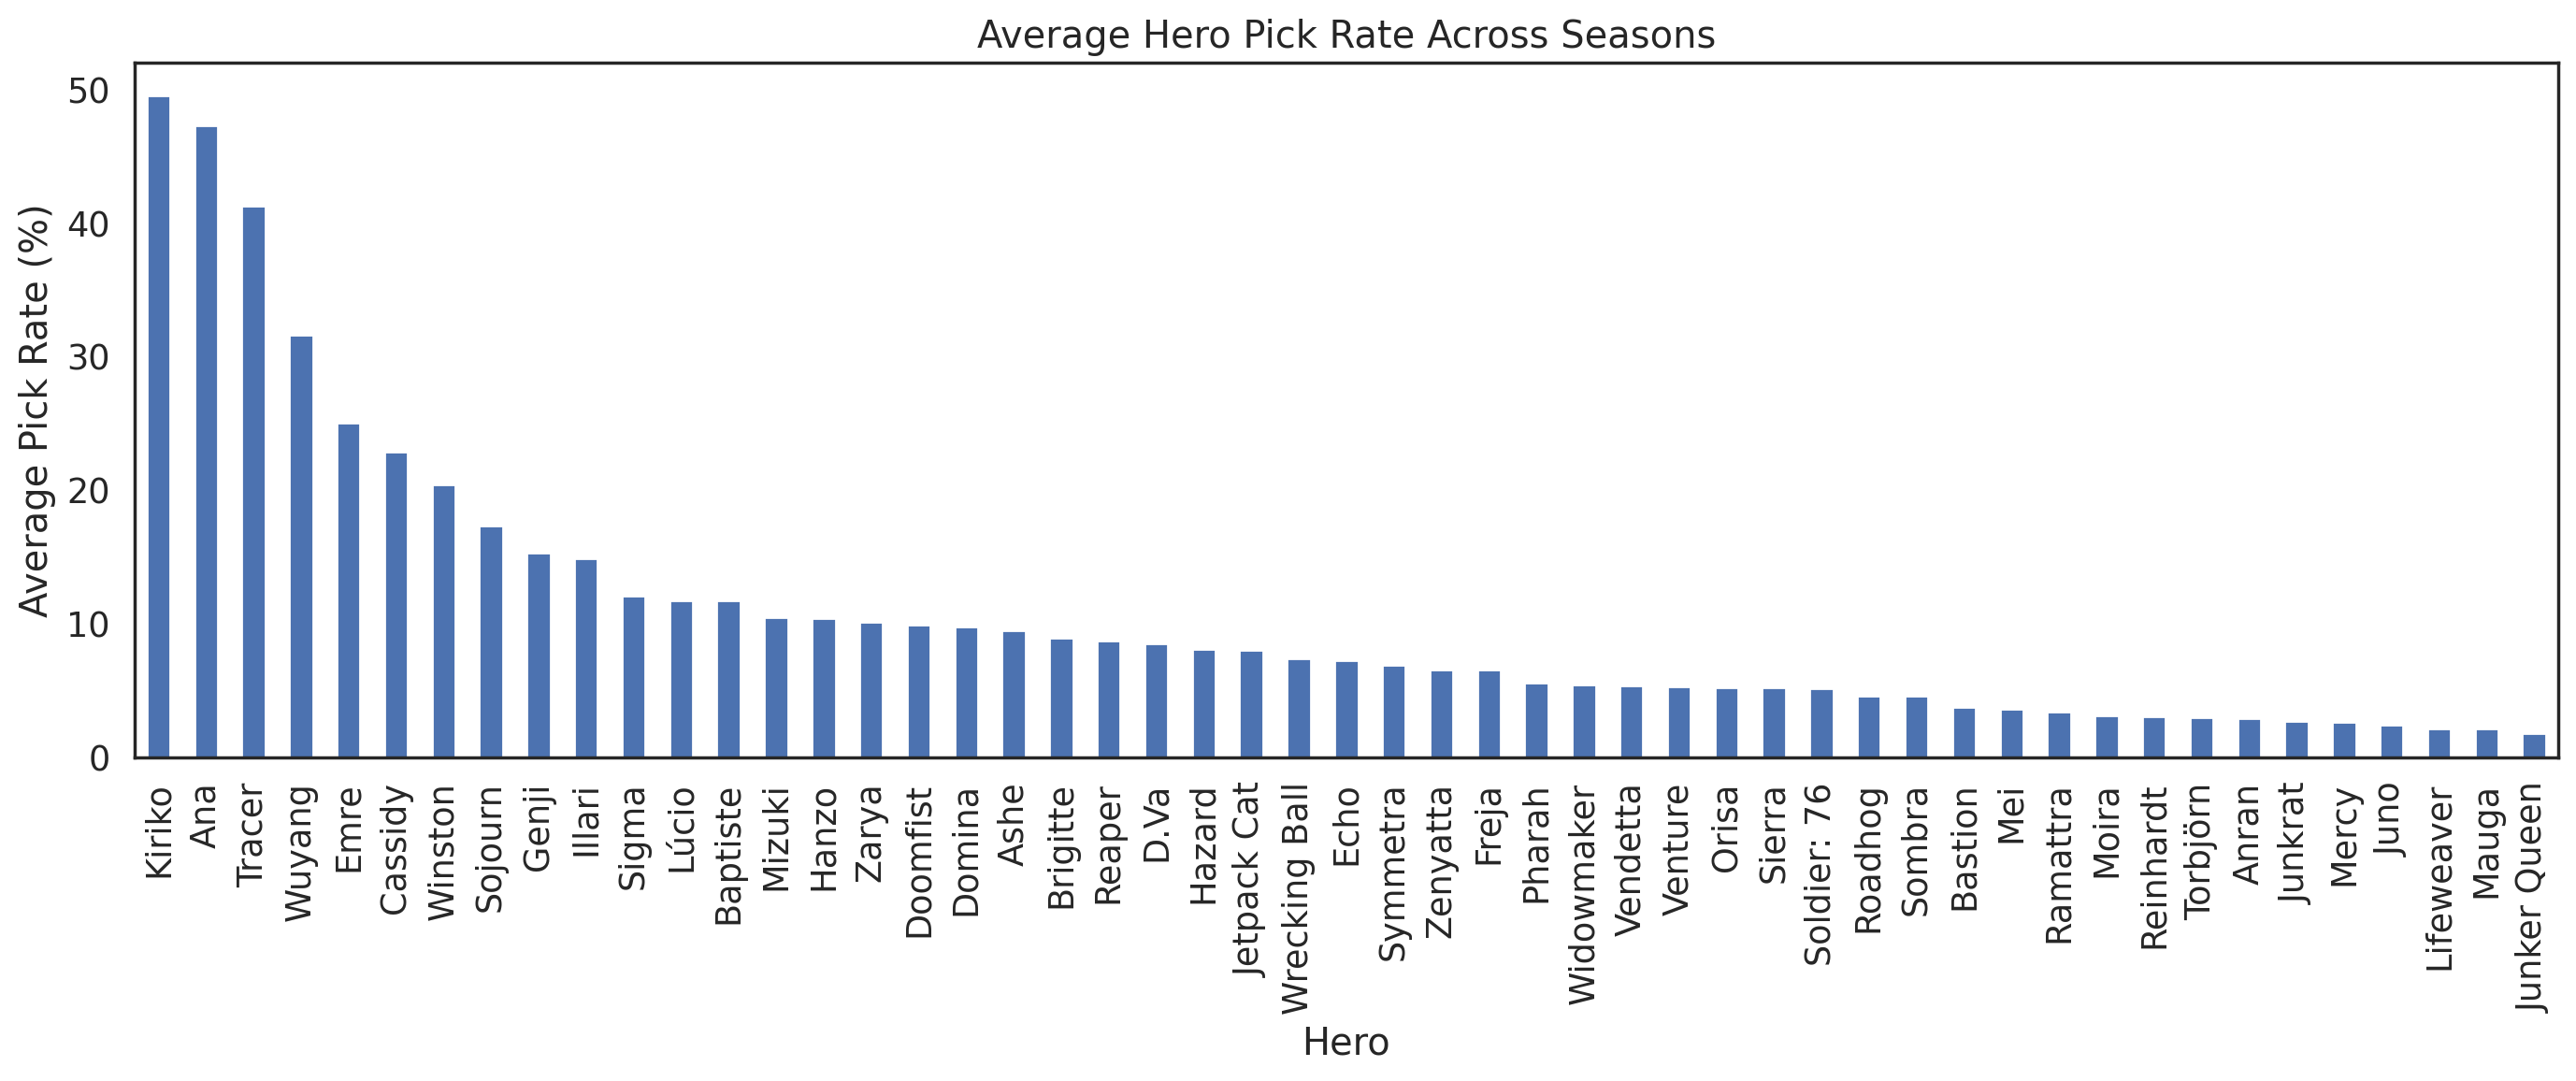


Entropy Values by Season:
   Season   Entropy
0      18  4.765413
1      19  4.755712
2      20  4.992229
3      21  5.020476
4      22  4.987969


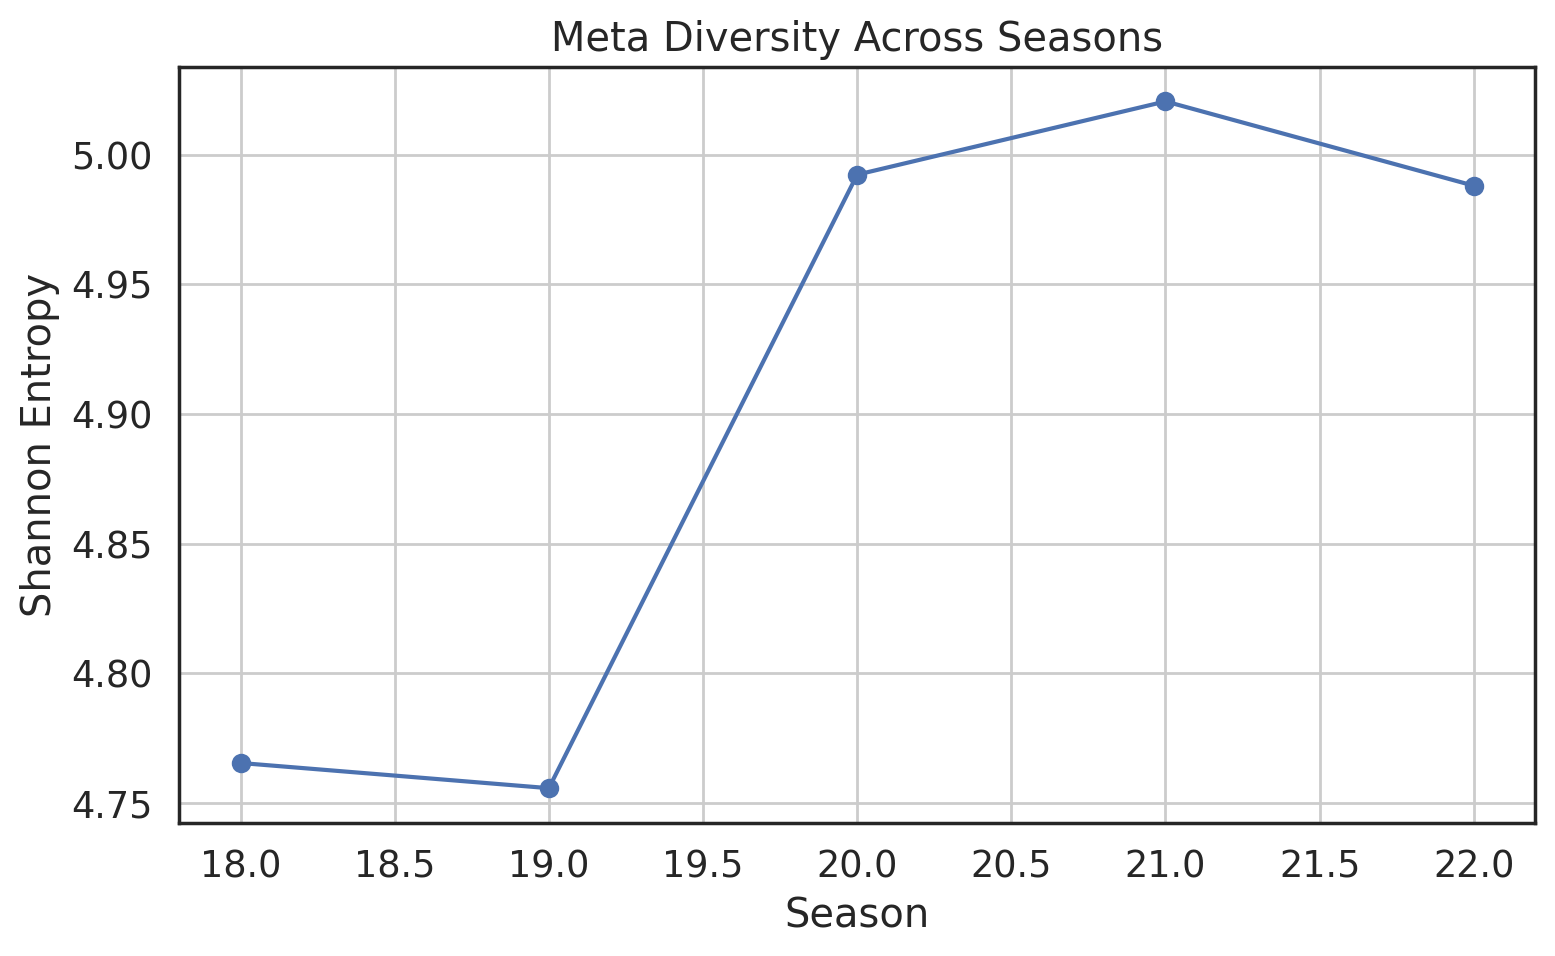

In [31]:
import matplotlib.pyplot as plt

# Load the cleaned combined hero dataset
heroes = pd.read_csv(
    'data/02-processed/all_heroes_pickrates_clean.csv'
)

# Display first few rows of dataset
print(heroes.head())

# Display shape of dataset
print("\nDataset Shape:", heroes.shape)


# ---------------------------------------------------
# HERO PICK RATE DISTRIBUTION
# ---------------------------------------------------

# Group heroes by Hero name
# Compute average Pick Rate across all seasons
# Sort from highest to lowest pick rate
hero_avg = (
    heroes.groupby('Hero')['Pick Rate']
    .mean()
    .sort_values(ascending=False)
)

# Create figure size
plt.figure(figsize=(14,6))

# Create bar chart
hero_avg.plot(kind='bar')

# Add chart title and labels
plt.title('Average Hero Pick Rate Across Seasons')
plt.xlabel('Hero')
plt.ylabel('Average Pick Rate (%)')

# Rotate hero names for readability
plt.xticks(rotation=90)

# Automatically adjust spacing
plt.tight_layout()

# Show plot
plt.show()


# ---------------------------------------------------
# SHANNON ENTROPY CALCULATION
# ---------------------------------------------------

# Create empty list to store entropy values
entropy_values = []

# Loop through each season
for season in sorted(heroes['Season'].unique()):

    # Filter dataset for current season
    season_df = heroes[
        heroes['Season'] == season
    ]

    # Convert Pick Rate into probabilities
    probabilities = (
        season_df['Pick Rate']
        / season_df['Pick Rate'].sum()
    )

    # Compute Shannon entropy
    entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    # Save season and entropy value
    entropy_values.append({
        'Season': season,
        'Entropy': entropy
    })

# Convert entropy results into dataframe
entropy_df = pd.DataFrame(entropy_values)

# Print entropy table
print("\nEntropy Values by Season:")
print(entropy_df)


# ---------------------------------------------------
# ENTROPY VISUALIZATION
# ---------------------------------------------------

# Create figure
plt.figure(figsize=(8,5))

# Create line plot of entropy across seasons
plt.plot(
    entropy_df['Season'],
    entropy_df['Entropy'],
    marker='o'
)

# Add chart title and labels
plt.title('Meta Diversity Across Seasons')
plt.xlabel('Season')
plt.ylabel('Shannon Entropy')

# Add grid for readability
plt.grid(True)

# Adjust spacing
plt.tight_layout()

# Display plot
plt.show()

#### Section 2 of EDA: Pick Rate and Win Rate Relationships
Next, we investigate whether heroes with higher pick rates also tend to have higher win rates.

The scatterplot compares hero popularity and competitive success. If highly picked heroes also maintain strong win rates, this may indicate that certain heroes provide competitive advantages within the meta.

We also compute the correlation between pick rate and win rate to quantitatively measure the strength of this relationship.

Finally, we analyze average pick rates across roles and seasons to observe how role balance evolves over time. Changes in role concentration may reflect balance patches, hero reworks, or shifting professional strategies.

Overall, these results suggest that hero popularity, effectiveness, and role balance all contribute to shaping the Overwatch 2 competitive meta.

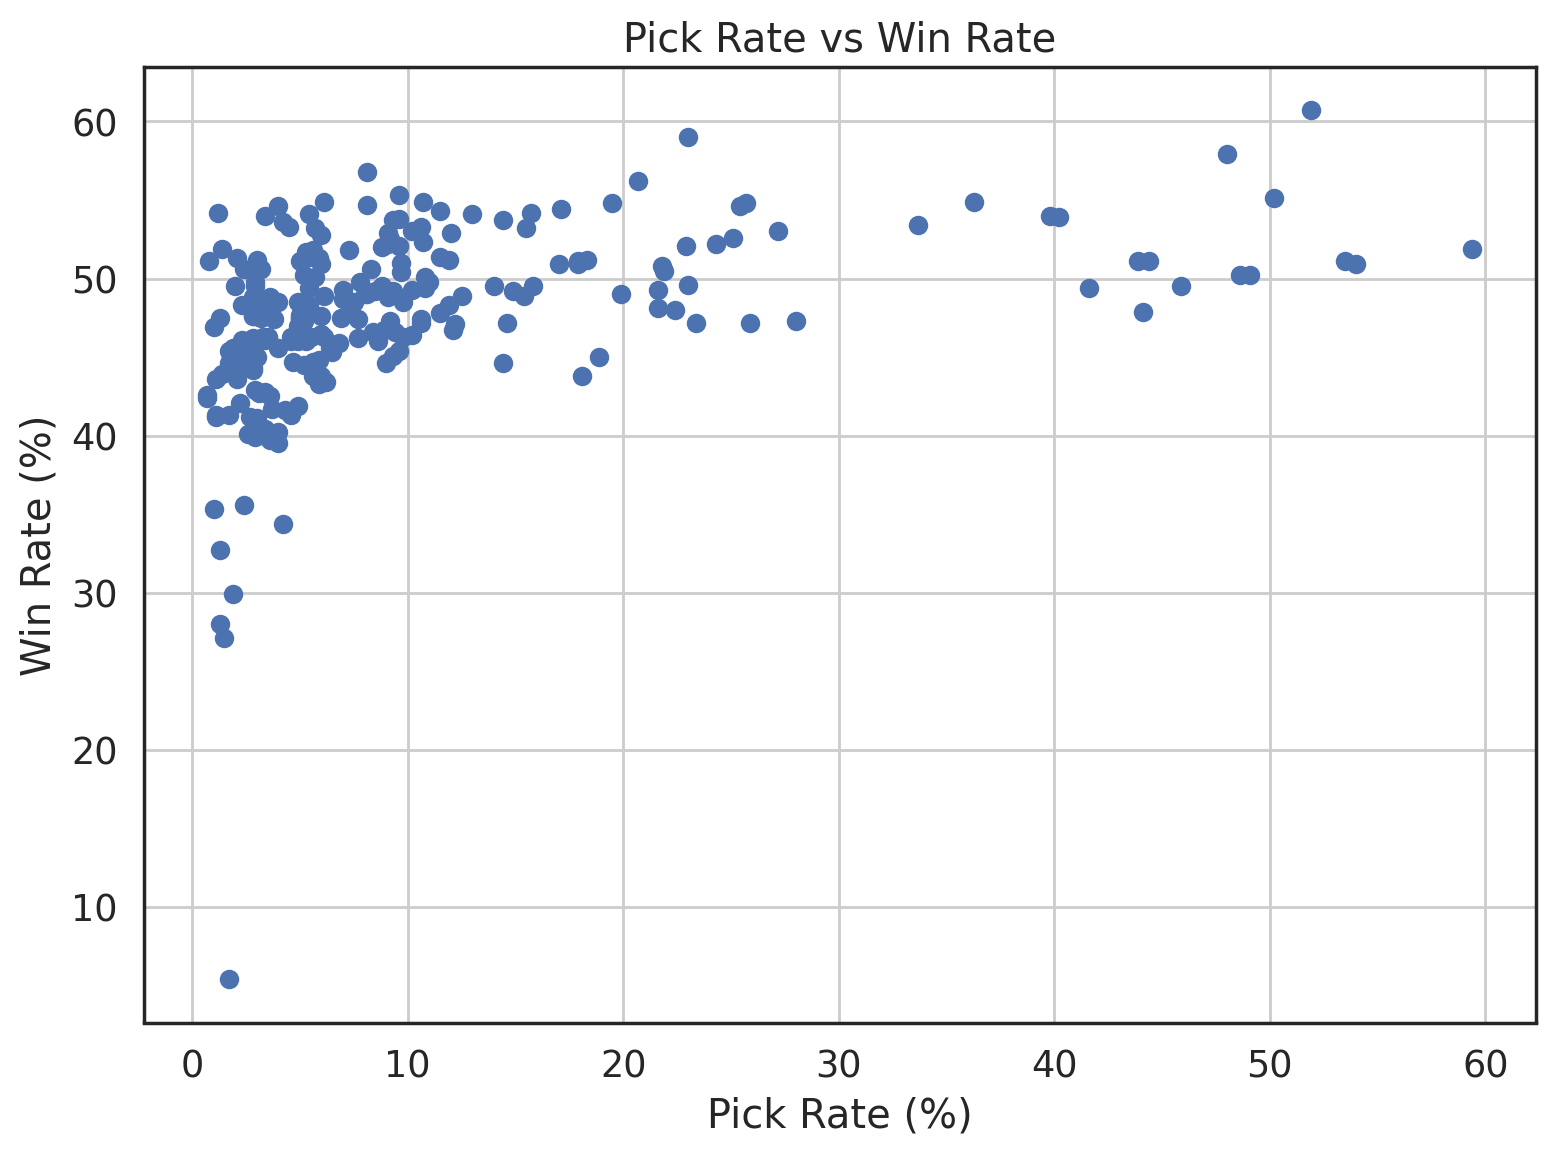

Correlation between Pick Rate and Win Rate: 0.404


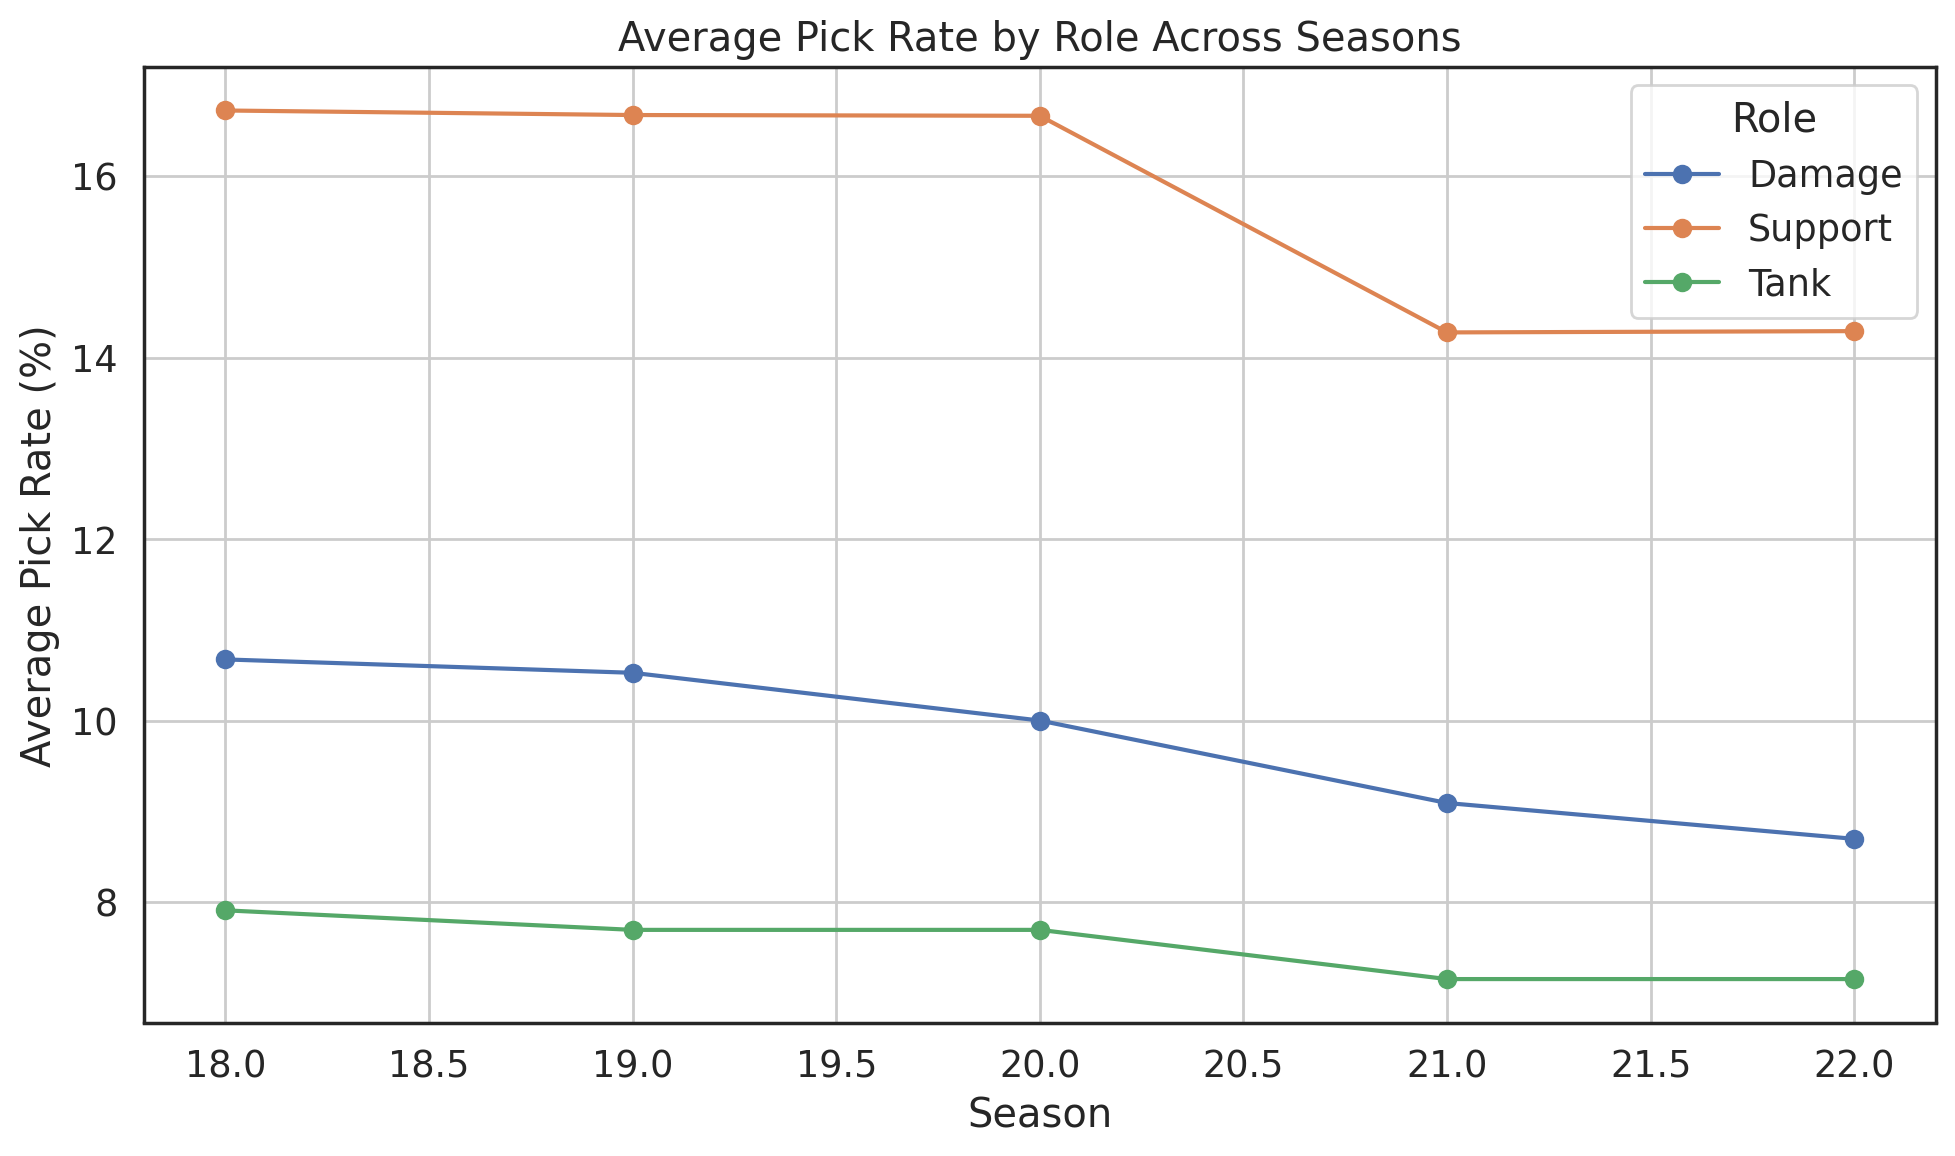

In [32]:
# ---------------------------------------------------
# PICK RATE VS WIN RATE RELATIONSHIP
# ---------------------------------------------------

# Create figure
plt.figure(figsize=(8,6))

# Create scatterplot comparing Pick Rate and Win Rate
plt.scatter(
    heroes['Pick Rate'],
    heroes['Win Rate']
)

# Add chart title and labels
plt.title('Pick Rate vs Win Rate')
plt.xlabel('Pick Rate (%)')
plt.ylabel('Win Rate (%)')

# Add grid for readability
plt.grid(True)

# Adjust spacing
plt.tight_layout()

# Show plot
plt.show()


# ---------------------------------------------------
# CORRELATION CALCULATION
# ---------------------------------------------------

# Compute correlation between Pick Rate and Win Rate
correlation = heroes['Pick Rate'].corr(
    heroes['Win Rate']
)

# Print correlation result
print(
    "Correlation between Pick Rate and Win Rate:",
    round(correlation, 3)
)


# ---------------------------------------------------
# ROLE TRENDS ACROSS SEASONS
# ---------------------------------------------------

# Group data by Season and Role
# Compute average Pick Rate
# Convert Role values into separate columns
role_season = (
    heroes.groupby(
        ['Season', 'Role']
    )['Pick Rate']
    .mean()
    .unstack()
)

# Create line plot
role_season.plot(
    figsize=(10,6),
    marker='o'
)

# Add chart title and labels
plt.title(
    'Average Pick Rate by Role Across Seasons'
)

plt.xlabel('Season')
plt.ylabel('Average Pick Rate (%)')

# Add grid for readability
plt.grid(True)

# Adjust spacing
plt.tight_layout()

# Show plot
plt.show()

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function: Calculate Shannon Entropy for a given DataFrame
def calculate_season_entropy(df):
    # Normalize Pick Rate to represent a probability distribution
    probs = df['Pick Rate'] / df['Pick Rate'].sum()
    # Calculate Shannon Entropy: H = -sum(p * log2(p))
    # Added a small constant (1e-9) to avoid log(0) errors
    entropy = -np.sum(probs * np.log2(probs + 1e-9))
    return entropy

# List of seasons to analyze
season_ids = [18, 19, 20, 21, 22]
entropy_results = []

for s in season_ids:
    # Concatenate hero data from all roles for the current season
    # Assumes dataframes like 'Damage_hero_s18' are already loaded in the environment
    all_heroes_s = pd.concat([
        globals()[f'Damage_hero_s{s}'], 
        globals()[f'Tank_hero_s{s}'], 
        globals()[f'Support_hero_s{s}']
    ])
    
    # Compute entropy and store the result
    ent = calculate_season_entropy(all_heroes_s)
    entropy_results.append({'season': s, 'entropy': ent})

# Create a DataFrame to store results
df_entropy = pd.DataFrame(entropy_results)
print("Meta Diversity (Shannon Entropy) per Season:")
print(df_entropy)

Meta Diversity (Shannon Entropy) per Season:
   season   entropy
0      18  4.765413
1      19  4.755712
2      20  4.992229
3      21  5.020476
4      22  4.987969


/tmp/ipykernel_419/3244549638.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_heroes_s22, x='Hero', y='Pick Rate', palette='viridis')


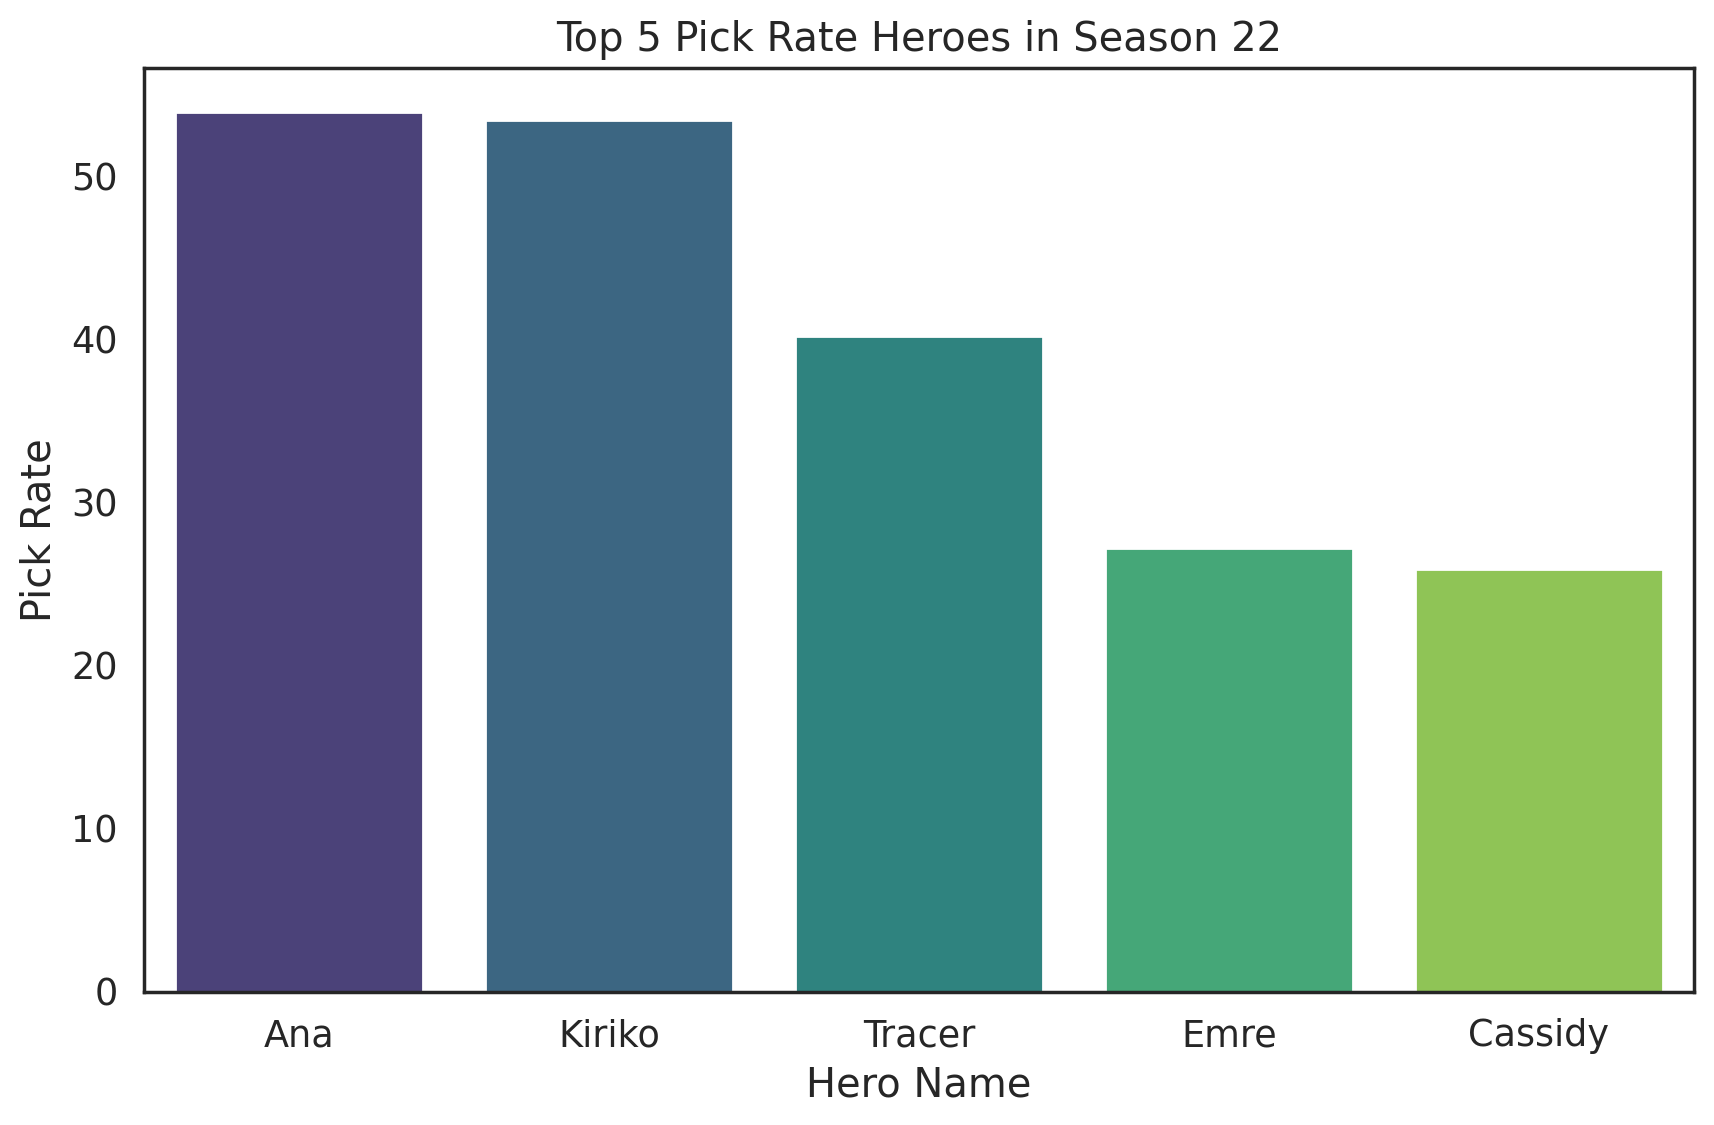

/tmp/ipykernel_419/3244549638.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_heroes_s21, x='Hero', y='Pick Rate', palette='viridis')


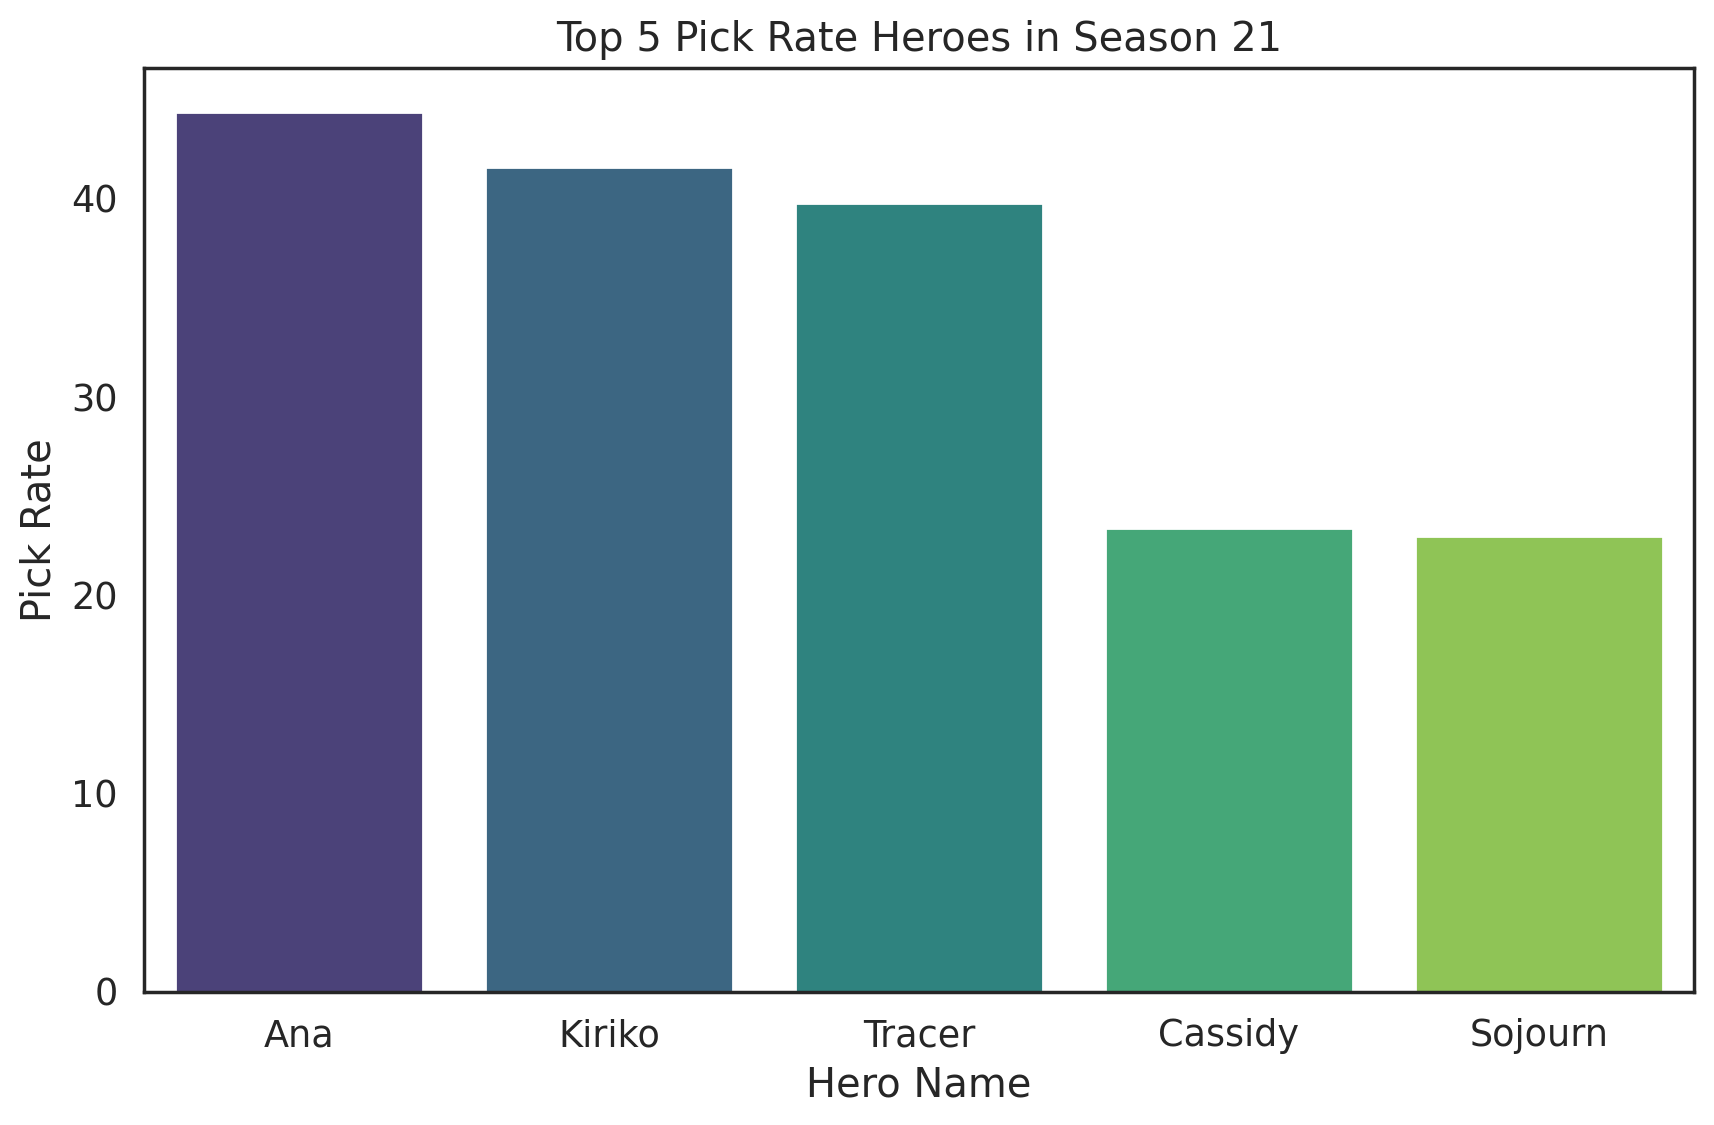

/tmp/ipykernel_419/3244549638.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_heroes_s20, x='Hero', y='Pick Rate', palette='viridis')


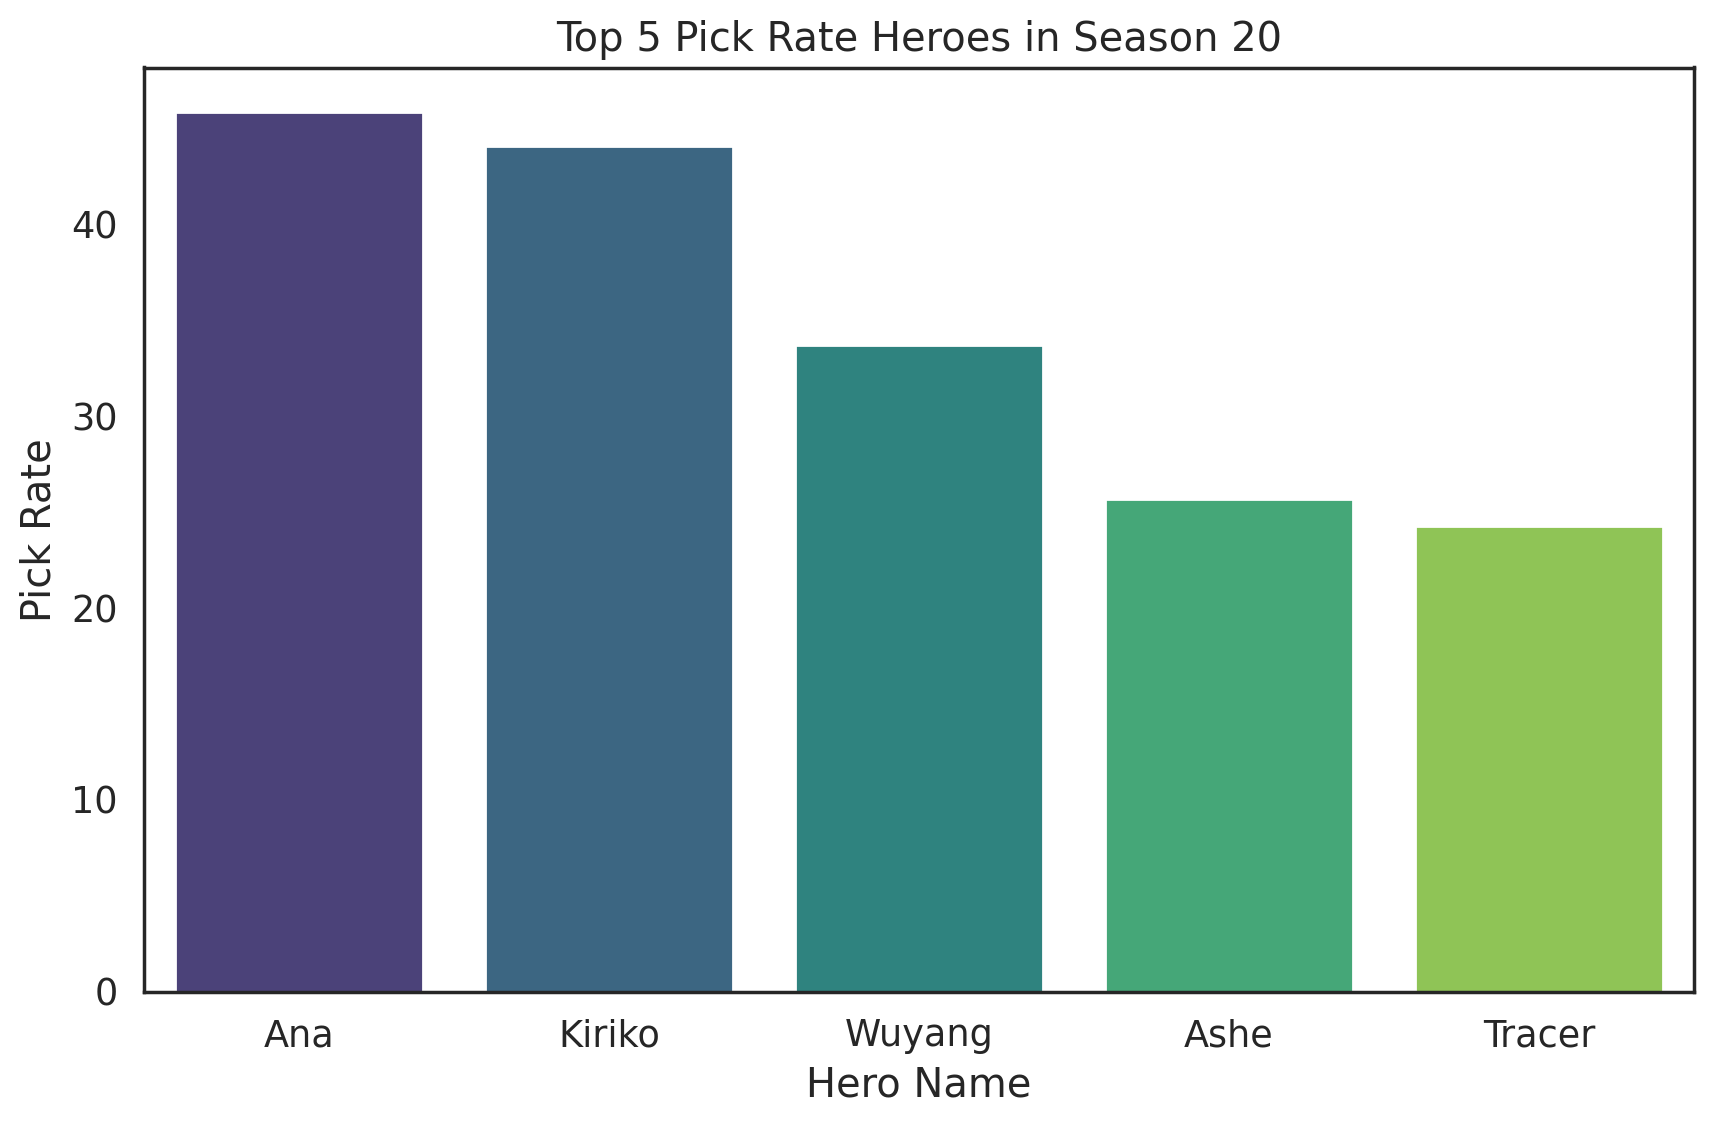

/tmp/ipykernel_419/3244549638.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_heroes_s19, x='Hero', y='Pick Rate', palette='viridis')


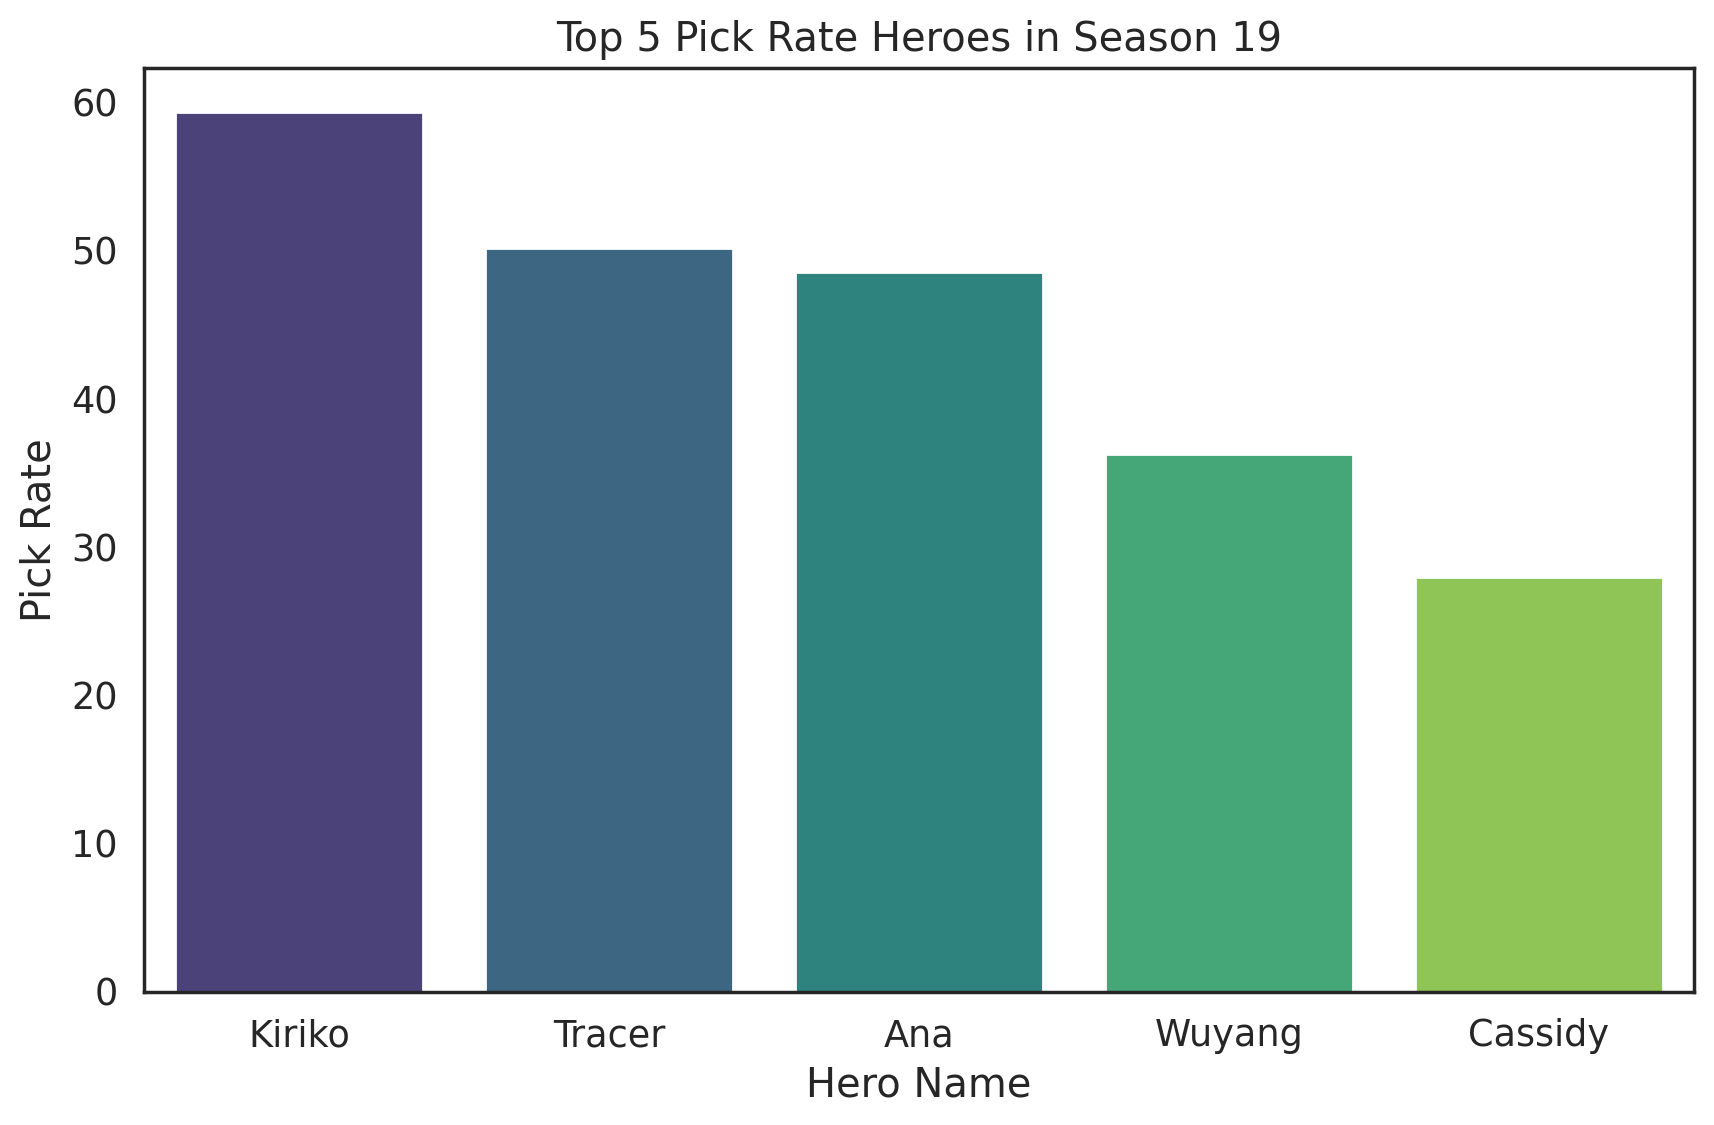

/tmp/ipykernel_419/3244549638.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_heroes_s18, x='Hero', y='Pick Rate', palette='viridis')


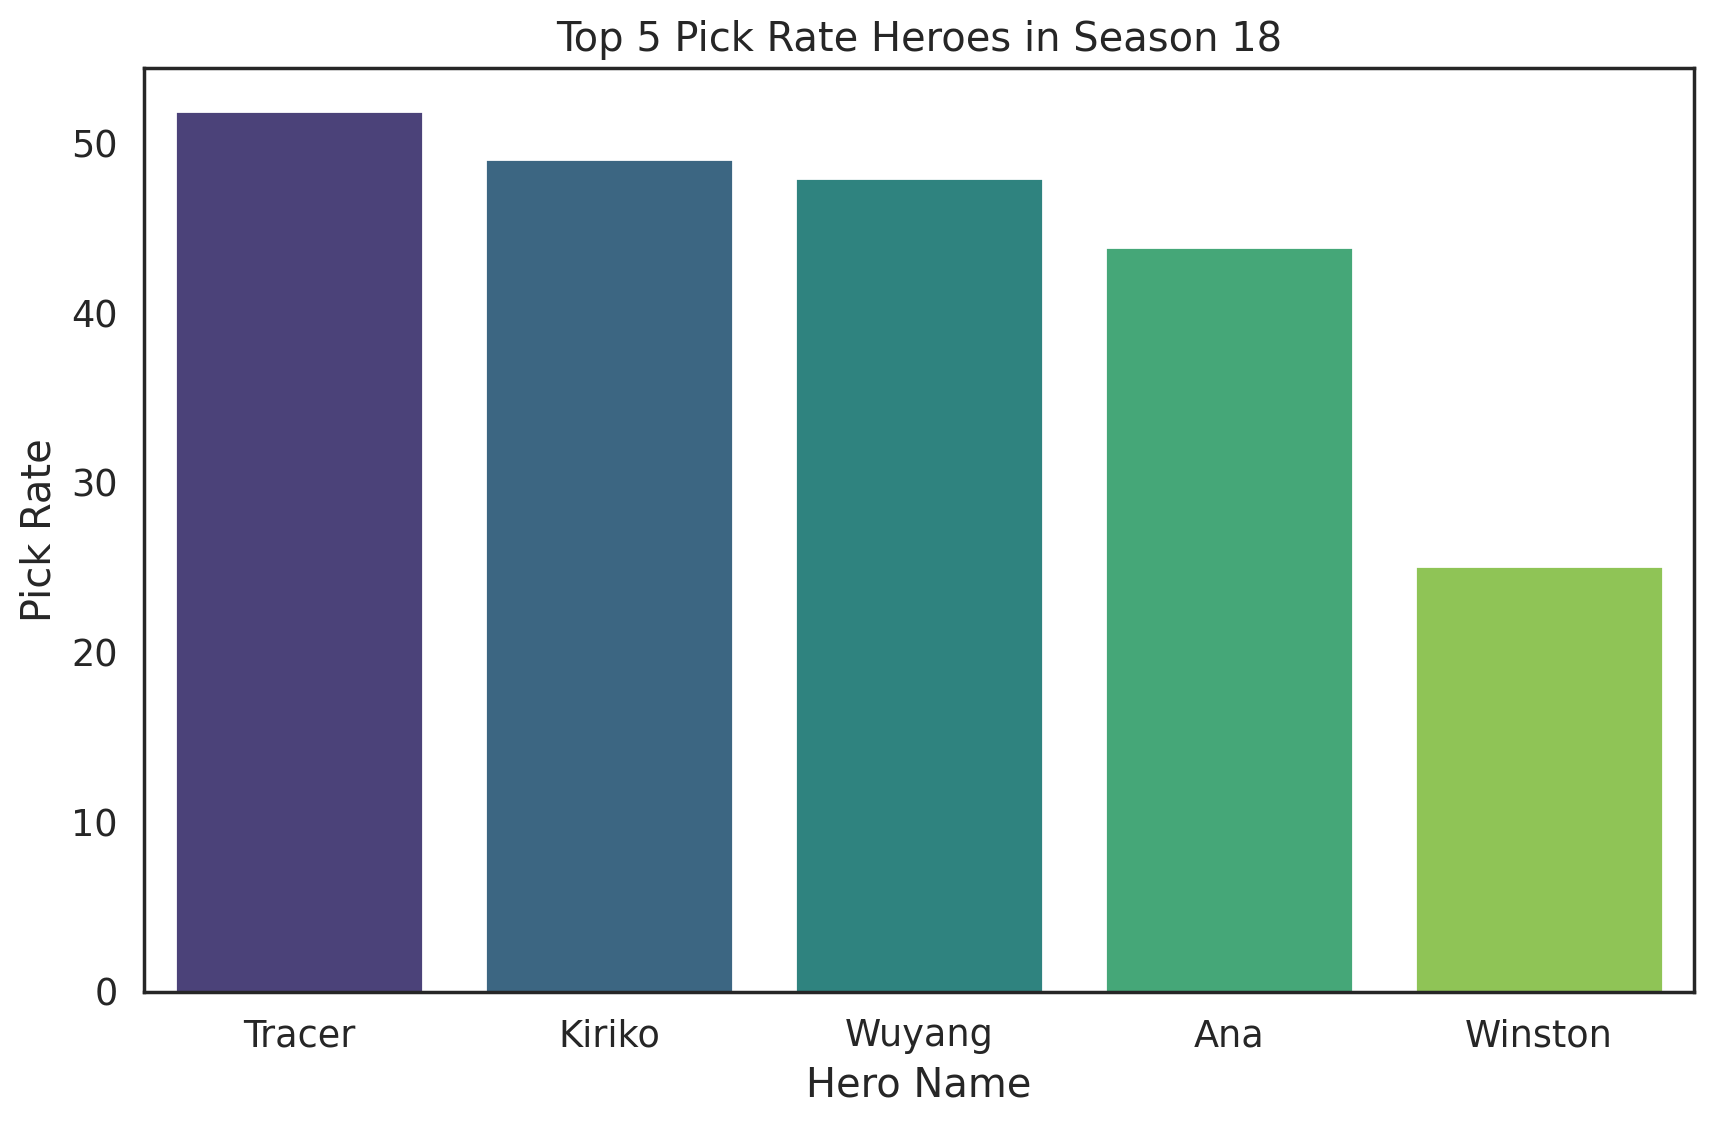

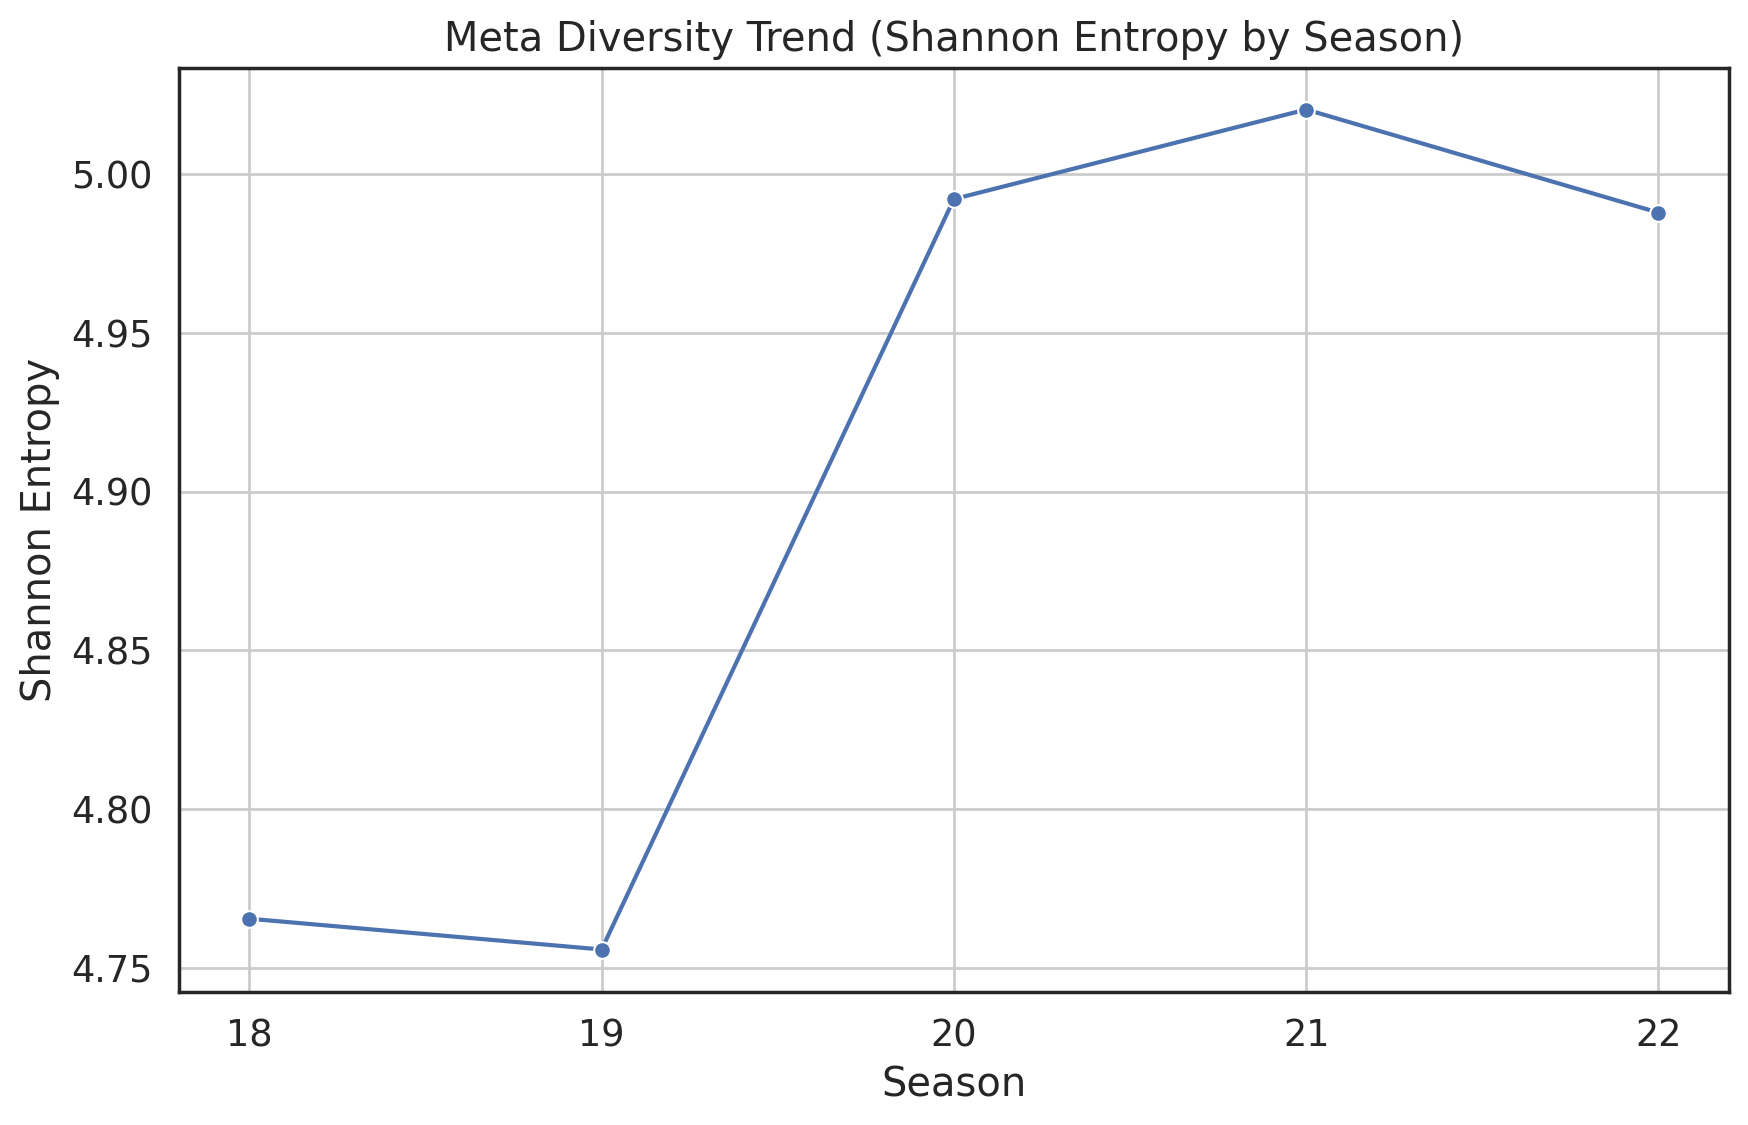

In [17]:
# Hero Dominance Plot 
top_heroes_s22 = pd.concat([Damage_hero_s22, Tank_hero_s22, Support_hero_s22]).nlargest(5, 'Pick Rate')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_heroes_s22, x='Hero', y='Pick Rate', palette='viridis')
plt.title('Top 5 Pick Rate Heroes in Season 22')
plt.xlabel('Hero Name')
plt.ylabel('Pick Rate')
plt.show()

top_heroes_s21 = pd.concat([Damage_hero_s21, Tank_hero_s21, Support_hero_s21]).nlargest(5, 'Pick Rate')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_heroes_s21, x='Hero', y='Pick Rate', palette='viridis')
plt.title('Top 5 Pick Rate Heroes in Season 21')
plt.xlabel('Hero Name')
plt.ylabel('Pick Rate')
plt.show()

top_heroes_s20 = pd.concat([Damage_hero_s20, Tank_hero_s20, Support_hero_s20]).nlargest(5, 'Pick Rate')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_heroes_s20, x='Hero', y='Pick Rate', palette='viridis')
plt.title('Top 5 Pick Rate Heroes in Season 20')
plt.xlabel('Hero Name')
plt.ylabel('Pick Rate')
plt.show()

top_heroes_s19 = pd.concat([Damage_hero_s19, Tank_hero_s19, Support_hero_s19]).nlargest(5, 'Pick Rate')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_heroes_s19, x='Hero', y='Pick Rate', palette='viridis')
plt.title('Top 5 Pick Rate Heroes in Season 19')
plt.xlabel('Hero Name')
plt.ylabel('Pick Rate')
plt.show()

top_heroes_s18 = pd.concat([Damage_hero_s18, Tank_hero_s18, Support_hero_s18]).nlargest(5, 'Pick Rate')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_heroes_s18, x='Hero', y='Pick Rate', palette='viridis')
plt.title('Top 5 Pick Rate Heroes in Season 18')
plt.xlabel('Hero Name')
plt.ylabel('Pick Rate')
plt.show()

# 2. Meta Diversity Trend Line Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_entropy, x='season', y='entropy', marker='o')
plt.title('Meta Diversity Trend (Shannon Entropy by Season)')
plt.xticks(season_ids)
plt.ylabel('Shannon Entropy')
plt.xlabel('Season')
plt.grid(True)
plt.show()

Correlation between Meta Diversity and Player Count: -0.1007


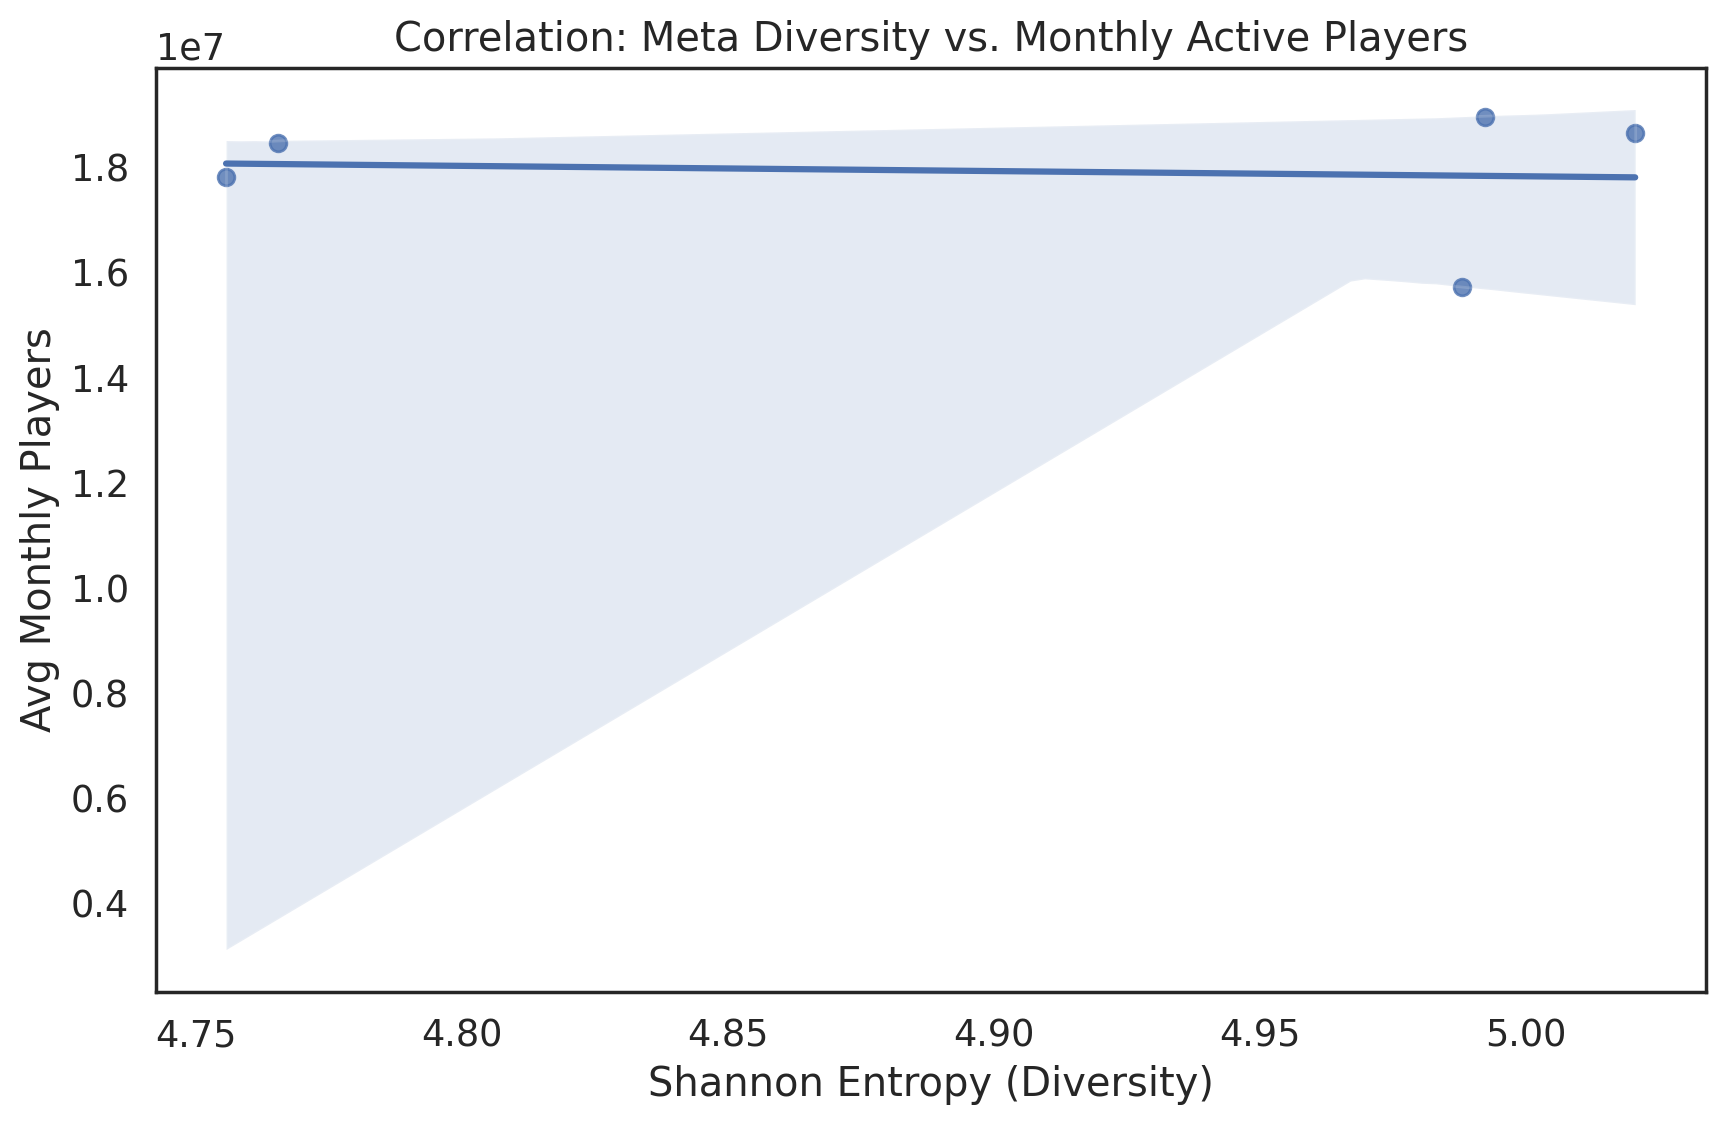

In [18]:
# Merge entropy results with the pre-loaded Player_counts_season dataframe
analysis_df = pd.merge(df_entropy, Player_counts_season, on='season')

# Calculate Pearson correlation coefficient
correlation = analysis_df['entropy'].corr(analysis_df['avg_monthly_players'])
print(f"Correlation between Meta Diversity and Player Count: {correlation:.4f}")

# Visualize the correlation with a regression plot
plt.figure(figsize=(10, 6))
sns.regplot(data=analysis_df, x='entropy', y='avg_monthly_players')
plt.title('Correlation: Meta Diversity vs. Monthly Active Players')
plt.xlabel('Shannon Entropy (Diversity)')
plt.ylabel('Avg Monthly Players')
plt.show()

## Ethics 

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Example of how to use the checkbox, and also of how you can put in a short paragraph that discusses the way this checklist item affects your project.  Remove this paragraph and the X in the checkbox before you fill this out for your project

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 - [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

### D. Modeling
 - [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


## Team Expectations 

- Communication: Check-ins every week via either a Discord call or an Instagram group chat. Must respond to group chat questions/messages within 24 hours, Monday-Friday.

- Work quality: If someone writes code, it must be reviewed by at least one other group member. The whole group must agree with merging into the main.

- Conflict resolution: All conflicts must be discussed in the group chat with every member’s input. If there isn't a consensus, members must take a vote, and the majority vote goes.

- Accountability: If a deadline cannot be met, notify the group at least 48 hours in advance.


## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
|04/27 |  18:00 | Read rubric; finalize research question wording  | Confirm scope, assign background research sections | 
| 04/29 | 20:00 |  Background research complete; identify all data sources | Finalize proposal draft; review ethics section as a group | 
| 04/29 |22:00 | Edit and submit proposal; begin scraping Winston's Lab + SteamCharts  | Review scraping output; troubleshoot data gaps   |
| 05/14  |17:00  | Data wrangled into clean CSVs; basic EDA complete| Review EDA visualizations; confirm entropy metric approach   |
| 05/17 | 17:00 | Statistical analysis complete (correlation + lagged regression) | Discuss findings; assign results/discussion writing |
| 05/27| 17:00  | Draft results and discussion written| Full group review; finalize visualizations |
| 6/10  | Before 11:59 PM  | Final edits complete| Submit final project and group surveys |

